# <img src="https://upload.wikimedia.org/wikipedia/commons/6/60/NISAR_artist_concept.jpg" width=400 align="left"/>
<img src="https://upload.wikimedia.org/wikipedia/commons/9/9b/NISAR_Mission_Logo.png" width=400 align="left"/><br><br><br><br><br>

# NISAR: Bi-temporal Change Detection

This notebook shows a workflow for pulling NASA/ISRO **NISAR** L-band SAR data, subsetting it,
and running a simple pre/post disturbance change-detection analysis — designed to run both in Jupyter Environment, this can also be adapted to run in ArcGIS Notebooks.


**Workflow**

1. Search & stream NISAR GCOV data from the ASF DAAC for a chosen track/frame and date
2. Subset to a small area of interest
3. Plot pre- and post-event images side by side
4. Apply a 5×5 median filter to reduce speckle
5. Compute an HV log-ratio "change" image
6. Interpret the output
7. Export the result to GeoTIFF

---

NISAR launched in July 2025. As of this writing, ASF has only released **pre-calibration**
L-band data, covering acquisitions from **October 17, 2025 to January 20, 2026** (fully
calibrated global data is expected Summer 2026). Any site for this notebook needs repeat coverage over the same track/frame before and after. This notebook does not hard-code a track/frame:
pre-calibration coverage is sparse and wasn't planned around this fire, so Step 1 searches the
catalog live and you pick a real matching pre/post pair from the results.

**Product — GCOV.** Level-2 Geocoded Polarimetric Covariance: already terrain-corrected and
projected to UTM. Note: **pre-calibration** release is notradiometrically calibrated yet, so treat backscatter as *relative*, not absolute.

---


## Setup

Detect the environment and install the packages we need. `arcpy` should import
inside an Esri Python environment (ArcGIS Pro or an Enterprise/Online notebook with the Esri
runtime)

In [16]:
# ------------------------------------------------------------------
# Environment check + package setup
# ------------------------------------------------------------------
# This cell checks whether we're running inside ArcGIS Pro's Python
# (arcpy available) or a standalone Python install, then makes sure
# the extra packages this notebook needs are installed.
#
# IMPORTANT (this trips people up): ArcGIS Pro's DEFAULT Python
# environment ("arcgispro-py3") is READ-ONLY by design, so Esri can
# guarantee it never breaks from a bad package install. That means
# pip installs below will FAIL with a permissions error unless you're
# running from a CLONED environment.
#
# To use a clone in ArcGIS Pro:
#   1. Package Manager > Active Environment > select your clone
#   2. Restart ArcGIS Pro (env changes require a restart)
#   3. Re-open this notebook — it will now run on the clone's Python
#
# If you're running this OUTSIDE ArcGIS Pro (plain Python/Jupyter),
# none of this applies — arcpy just won't be available, and pip
# installs will work normally in whatever env you're in.
# ------------------------------------------------------------------

import importlib.util, subprocess, sys

# Check for arcpy — tells us if we're inside an ArcGIS Pro Python env at all
HAS_ARCPY = importlib.util.find_spec("arcpy") is not None
print(f"arcpy available: {HAS_ARCPY}")

# Sanity check: which Python is actually running this cell?
# Handy for confirming you're pointed at the clone, not the base env.
print(f"Python executable: {sys.executable}")

# Packages this notebook needs beyond the ArcGIS Pro / standard library defaults
REQUIRED = ["earthaccess", "h5py", "rasterio", "scipy", "pyproj", "matplotlib"]

# find_spec checks for a package without importing it —
# avoids unnecessary import side effects just to check availability
missing = [pkg for pkg in REQUIRED if importlib.util.find_spec(pkg) is None]

if missing:
    print(f"Installing: {missing}")
    try:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "--quiet", *missing],
            check=True
        )
        print("Done. Restart the kernel if any import still fails, then re-run this cell.")
    except subprocess.CalledProcessError as e:
        # Most common cause in ArcGIS Pro: still pointed at the read-only
        # base environment instead of a clone. See note above.
        print("pip install failed — check that you're running on a CLONED")
        print("(writable) environment, not the default read-only arcgispro-py3.")
        print(e)
else:
    print("All required packages already available.")

arcpy available: False
Python executable: /Users/peacock/miniforge3/envs/NISAR_Disturbance/bin/python
All required packages already available.


## Step 1 — Search & stream NISAR GCOV data from ASF

We search ASF for GCOV products
intersecting our area of interest, filtered to the pre-calibration release window. Edit
`AOI_BBOX` and the two date windows below to point at a different place/event.


`earthaccess` handles NASA Earthdata Login. 
`earthaccess.login()` prompts for your Earthdata username/password the first time (free account
at urs.earthdata.nasa.gov) and caches it in `~/.netrc` after that.

In [17]:
import earthaccess

auth = earthaccess.login()
print("Authenticated:", bool(auth))

Authenticated: True


In [18]:
# Area of interest
box_left, box_bottom, box_right, box_top = 147.67, -35.94, 147.986, -35.75

# Baseline window and post-change window. Both must sit inside the public
# pre-calibration archive: 2025-10-17 through 2026-01-20.
PRE_DATE_RANGE = ("2025-11-01", "2025-12-01")   # date baseline window, before disturbance
POST_DATE_RANGE = ("2026-01-01", "2026-01-20")  # date window after disturbance

def search_gcov(date_range):
    # Pre-calibration beta short_name; see note below if this returns nothing.
    return earthaccess.search_data(
        short_name="NISAR_L2_GCOV_BETA_V1",
        bounding_box=(box_left, box_bottom, box_right, box_top),
        temporal=date_range,
        count=50,
    )

pre_results = search_gcov(PRE_DATE_RANGE)
post_results = search_gcov(POST_DATE_RANGE)

print(f"Pre-change candidates: {len(pre_results)}")
print(f"Post-post candidates: {len(post_results)}")

Pre-change candidates: 1
Post-post candidates: 1


In [7]:
# Inspect what track/frame/date combinations are actually available.
def summarize(results, label):
    print(f"--- {label} ---")
    for g in results:
        meta = g["umm"]
        gran_id = meta.get("GranuleUR", "unknown")
        temporal = meta.get("TemporalExtent", {}).get("RangeDateTime", {})
        start = temporal.get("BeginningDateTime", "?")
        print(f"  {gran_id}   acquired: {start}")

summarize(pre_results, "PRE-FIRE")
summarize(post_results, "POST-FIRE")

print()
print("NISAR granule IDs encode track/frame, e.g. ..._T167_F150_... Look for a PRE and")
print("POST granule that share the same track (T###) and frame (F###) - that's what")
print("guarantees matching geometry, which is required for a ratio-based change map.")

--- PRE-FIRE ---
  NISAR_L2_PR_GCOV_006_023_A_160_2005_DHDH_A_20251123T201000_20251123T201034_X05009_N_F_J_001   acquired: 2025-11-23T20:10:00.000000Z
--- POST-FIRE ---
  NISAR_L2_PR_GCOV_010_023_A_160_2005_DHDH_A_20260110T201002_20260110T201037_X05009_N_F_J_001   acquired: 2026-01-10T20:10:02.000000Z

NISAR granule IDs encode track/frame, e.g. ..._T167_F150_... Look for a PRE and
POST granule that share the same track (T###) and frame (F###) - that's what
guarantees matching geometry, which is required for a ratio-based change map.


In [8]:
# Pick a pre/post pair that share the same track/frame (encoded in the granule ID, e.g.
# "..._T167_F150_...") - matching geometry matters a lot for a ratio-based change map.
PRE_INDEX = 0
POST_INDEX = 0

import h5py

pre_file = earthaccess.open([pre_results[PRE_INDEX]])[0]
post_file = earthaccess.open([post_results[POST_INDEX]])[0]

pre_h5 = h5py.File(pre_file, "r")
post_h5 = h5py.File(post_file, "r")

# GCOV's geocoded grids live under this fixed group path (frequencyB instead of frequencyA
# if the acquisition used the secondary frequency - check pre_h5['science']['LSAR']['GCOV']
# ['grids'].keys() if frequencyA isn't present).
pre_grid = pre_h5["science"]["LSAR"]["GCOV"]["grids"]["frequencyA"]
post_grid = post_h5["science"]["LSAR"]["GCOV"]["grids"]["frequencyA"]
print("Variables:", list(pre_grid.keys()))

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Variables: ['HHHH', 'HVHV', 'listOfCovarianceTerms', 'listOfPolarizations', 'mask', 'numberOfLooks', 'numberOfSubSwaths', 'projection', 'rtcGammaToSigmaFactor', 'xCoordinateSpacing', 'xCoordinates', 'yCoordinateSpacing', 'yCoordinates']


## Step 2 — Subset to an area of interest

It's recommended to subset the data to your area of interest - a full GCOV frame is on the order of several GB per polarization layer. `xCoordinates`/`yCoordinates` are the grid's UTM (or polar-stereographic)
coordinate arrays; `projection` is a scalar dataset holding the EPSG code. We transform our
lon/lat AOI into that CRS, find the matching row/col range, and slice the HDF5 dataset directly
— an `h5py` dataset slice only reads the requested bytes, so this is the "subset before
download" step.

In [10]:
import numpy as np
from pyproj import Transformer, CRS

x_coords = pre_grid["xCoordinates"][()]
y_coords = pre_grid["yCoordinates"][()]
epsg = int(pre_grid["projection"][()].item())
crs = CRS.from_epsg(epsg)
print("Detected EPSG:", epsg)

to_grid = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
x_min, y_min = to_grid.transform(box_left, box_bottom)
x_max, y_max = to_grid.transform(box_right, box_top)

# y is typically descending (north to south) - sort both ways to be safe.
col_start, col_end = sorted(np.searchsorted(x_coords, [x_min, x_max]))
row_start, row_end = sorted(np.searchsorted(-y_coords, [-y_max, -y_min]))

POL = "HVHV"  # cross-pol diagonal term (real-valued linear-power backscatter)
pre_hv = pre_grid[POL][row_start:row_end, col_start:col_end].astype("float32")
post_hv = post_grid[POL][row_start:row_end, col_start:col_end].astype("float32")

x_sub = x_coords[col_start:col_end]
y_sub = y_coords[row_start:row_end]
print("Subset shape:", pre_hv.shape)

pre_h5.close()
post_h5.close()

Detected EPSG: 32755
Subset shape: (1042, 1435)


## Step 3 — Plot pre/post side by side

GCOV stores linear-power backscatter. We convert to decibels (`10*log10(power)`) and clip to the
2nd–98th percentile, using the same color scale for both dates so brightness differences are
actually comparable. This is pre-calibration data, so treat dB values as relative, not
absolute.

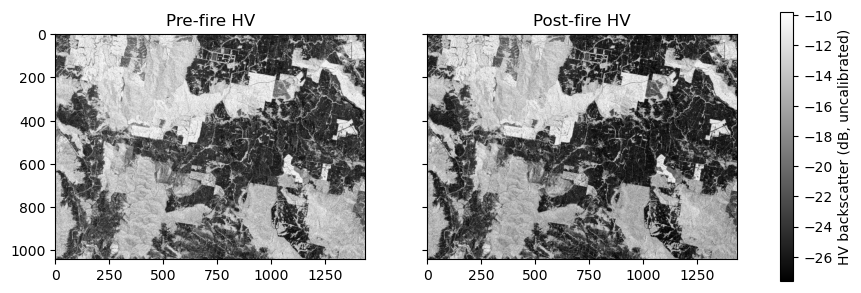

In [11]:
import matplotlib.pyplot as plt

def to_db(power, eps=1e-6):
    return 10 * np.log10(np.clip(power, eps, None))

pre_db, post_db = to_db(pre_hv), to_db(post_hv)
vmin, vmax = np.nanpercentile(np.concatenate([pre_db.ravel(), post_db.ravel()]), [2, 98])

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
axes[0].imshow(pre_db, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Pre-fire HV")
im = axes[1].imshow(post_db, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("Post-fire HV")
fig.colorbar(im, ax=axes, shrink=0.7, label="HV backscatter (dB, uncalibrated)")
plt.show()

## Step 4 — 5×5 median filter (speckle reduction)

SAR has multiplicative speckle from coherent interference within a resolution cell and it needs reducing before any pixel-wise comparison. We filter in
**linear power**, the conventional domain for SAR despeckling, not in dB.

In [12]:
from scipy.ndimage import median_filter

pre_hv_filt = median_filter(pre_hv, size=5)
post_hv_filt = median_filter(post_hv, size=5)

## Step 5 — HV log-ratio change

L-band HV is sensitive to volume scattering from vegetation structure, and the HV log ratio measures the logarithmic change in cross-polarized HV backscatter values between two dates. Because HV backscatter is strongly influenced by volume scattering linked to forest structure and biomass, this ratio is a useful indicator of forest disturbance. A decrease in HV typically reflects a loss of canopy cover and a reduction in vegetation volume.The change metric is a straightforward **log ratio** applied to the linear power data:

$$\text{HV log ratio}  = 10 \log_{10}\left(\frac{HV_{t1}}{HV_{t0}}\right)$$


$HV_{t0}$  -  first HV image <br>
$HV_{t1}$  -  second HV image <br>

* High values: HV backscatter increased from t0 to t1
* Low values: HV backscatter decreased from t0 to t1, suggesting forest disturbance
* Close to 0: little to no change in cross-polarized backscatter between dates

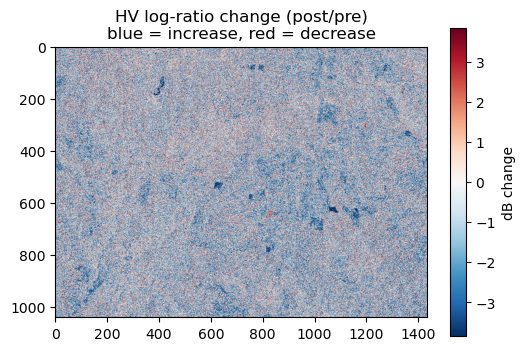

Mean: -0.90 dB   Std: 2.17 dB


In [14]:
ratio_db = 10 * np.log10(post_hv / pre_hv)
change_vmax = np.nanpercentile(np.abs(ratio_db), 90)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(ratio_db, cmap="RdBu_r", vmin=-change_vmax, vmax=change_vmax)
ax.set_title("HV log-ratio change (post/pre)\nblue = increase, red = decrease")
fig.colorbar(im, ax=ax, shrink=0.8, label="dB change")
plt.show()

print(f"Mean: {np.nanmean(ratio_db):.2f} dB   Std: {np.nanstd(ratio_db):.2f} dB")

## Step 6 — Output & interpretation

A quick, purely illustrative "changed" mask — not a validated burn-severity classifier.

Apply thresholding to bi-temporal change results to get an inital binary product.

Fraction flagged as changed (+/-3.0 dB): 19.6%


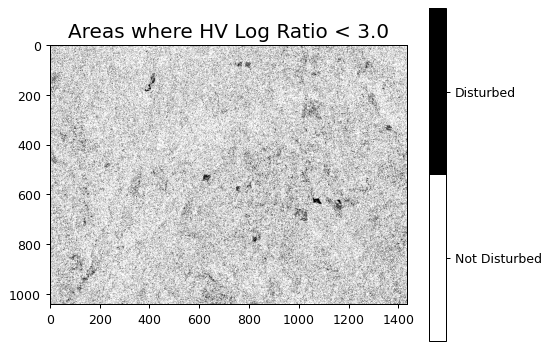

In [15]:
import matplotlib.colors as mcolors
threshold = 3.0
changed_mask = np.abs(ratio_db) > threshold
print(f"Fraction flagged as changed (+/-{threshold} dB): {np.mean(changed_mask):.1%}")
# plt.imshow(changed_mask, cmap="gray")
# plt.title(f"Illustrative changed-pixel mask (|ratio| > {THRESHOLD_DB} dB)")
# plt.show()

# Create colormap and norm
labels = ["Not Disturbed","Disturbed"]
colors = ["white", "black"] 
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([0, 1, 2], cmap.N)

# Plot
fig, ax = plt.subplots(dpi=90)
pos=ax.imshow(changed_mask, cmap=cmap)
cbar = fig.colorbar(pos, ax=ax, ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(labels)
ax.set_title(f'Areas where HV Log Ratio < {threshold}', fontsize=16)
plt.show()

## Step 7 — Export to GeoTIFF

We build the affine transform directly from the `x_sub`/`y_sub` coordinate arrays we already
sliced out in Step 2 (pixel spacing from consecutive coordinate values, origin offset by half a
pixel to go from pixel-center to pixel-corner), then write a 3-band GeoTIFF with `rasterio`.

**ArcGIS-specific tips:** in **ArcGIS Pro**, add the file via `arcpy` or drag it into Contents.

In [211]:
import rasterio

pixel_x = float(x_sub[1] - x_sub[0])
pixel_y = float(y_sub[1] - y_sub[0])  # typically negative (north-up)
transform = rasterio.Affine(pixel_x, 0.0, x_sub[0] - pixel_x / 2,
                             0.0, pixel_y, y_sub[0] - pixel_y / 2)

bands = np.stack([pre_db, post_db, ratio_db]).astype("float32")

out_dir = "/arcgis/home" if HAS_ARCPY else "."
out_path = f"{out_dir}/nisar_hv_change.tif"

with rasterio.open(
    out_path, "w",
    driver="GTiff",
    height=bands.shape[1],
    width=bands.shape[2],
    count=3,
    dtype="float32",
    crs=rasterio.CRS.from_epsg(epsg),
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(bands)
    dst.set_band_description(1, "Pre-fire HV (dB, despeckled)")
    dst.set_band_description(2, "Post-fire HV (dB, despeckled)")
    dst.set_band_description(3, "HV log-ratio change (dB)")

print(f"Wrote GeoTIFF to: {out_path}")

Wrote GeoTIFF to: ./nisar_hv_change.tif


---
## Sources

- [NISAR availability & release timeline](https://nisar-docs.asf.alaska.edu/availability-overview/)
- [NISAR GCOV product description](https://nisar-docs.asf.alaska.edu/gcov/)
- [ASF: Working with NISAR Sample Data](https://asf.alaska.edu/working-with-nisar-sample-data/)
- [Esri: A First Look at NISAR](https://www.esri.com/arcgis-blog/products/arcgis-pro/imagery/nisar-in-arcgis)
- [NISAR_Science Algorithms GitHub](https://github.com/NISAR-Science-Algorithms/)
